In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [3]:
df = pd.read_csv('/content/NBA_player_of_the_week.csv')

In [12]:
df.head()

,Age,Conference,Date,Draft Year,Height,Player,Position,Season,Season short,Seasons in league,Team,Weight,Real_value
0,29,0,"Apr 14, 1985",1978,6-5,Micheal Ray Richardson,PG,1984-1985,1985,6,New Jersey Nets,189,1.0
1,23,0,"Apr 7, 1985",1982,6-6,Derek Smith,SG,1984-1985,1985,2,Los Angeles Clippers,205,1.0
2,28,0,"Apr 1, 1985",1979,6-6,Calvin Natt,F,1984-1985,1985,5,Denver Nuggets,220,1.0
3,37,0,"Mar 24, 1985",1969,7-2,Kareem Abdul-Jabbar,C,1984-1985,1985,15,Los Angeles Lakers,225,1.0
4,28,0,"Mar 17, 1985",1978,6-9,Larry Bird,SF,1984-1985,1985,5,Boston Celtics,220,1.0


In [6]:
df.shape

(1145, 13)

In [10]:
df.isnull().sum()

,0
Age,0
Conference,0
Date,0
Draft Year,0
Height,0
Player,0
Position,0
Season,0
Season short,0
Seasons in league,0


In [9]:
df['Conference']=df['Conference'].fillna(df['Conference'].mode()[0])

In [11]:
df['Conference']=df['Conference'].map({'East':0,'West':1})

In [26]:
x = df.drop(['Real_value', 'Player', 'Position', 'Season', 'Season short', 'Team', 'Seasons in league'],axis=1)
y = df['Real_value']

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [28]:
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [29]:
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

DecisionTreeRegressor()

In [30]:
model.score(x_train, y_train)

1.0

In [31]:
model.score(x_test, y_test)

0.9059934318555007

In [32]:
pip install chefboost

In [34]:
from chefboost import Chefboost as chef
config = {
    "algorithm": "C4.5"
}

model = chef.fit(df, config=config, target_label='Real_value')

26-06-29 15:42:42 - ⚠️ You set the algorithm to C4.5 but the Decision column of your data set has non-object type.That's why, the algorithm is set to Regression to handle the data set.
26-06-29 15:42:42 - Regression tree is going to be built...
26-06-29 15:45:25 - -------------------------
26-06-29 15:45:25 - finished in 162.52228713035583 seconds
26-06-29 15:45:25 - -------------------------
26-06-29 15:45:25 - Evaluate train set
26-06-29 15:45:25 - -------------------------
26-06-29 15:45:25 - MAE: 0.0
26-06-29 15:45:25 - MSE: 0.0
26-06-29 15:45:25 - RMSE: 0.0
26-06-29 15:45:25 - RAE: 0.0
26-06-29 15:45:25 - RRSE 0.0
26-06-29 15:45:25 - Mean: 0.6676855895196506
26-06-29 15:45:25 - MAE / Mean: 0.0%
26-06-29 15:45:25 - RMSE / Mean: 0.0%


In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score # Changed to r2_score for regression

# Features and Target are already defined and preprocessed as `x` and `y` in previous cells.
# Using the preprocessed `x` and `y` for splitting.

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# CART Model
cart = DecisionTreeRegressor( # Corrected typo here
    criterion="friedman_mse", # Changed criterion to a valid one for regression
    random_state=42
)

cart.fit(X_train, y_train)

# Prediction
y_pred = cart.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred)) # Changed to print R2 Score

R2 Score: 0.9059934318555007


In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score # Changed to r2_score for regression

# Using the preprocessed `x` and `y` for splitting, as defined in previous cells.

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# ID3-like tree
id3 = DecisionTreeRegressor(
    criterion="friedman_mse", # Changed criterion to a valid one for regression
    random_state=42
)

id3.fit(X_train, y_train)

y_pred = id3.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred)) # Changed to print R2 Score

R2 Score: 0.9059934318555007


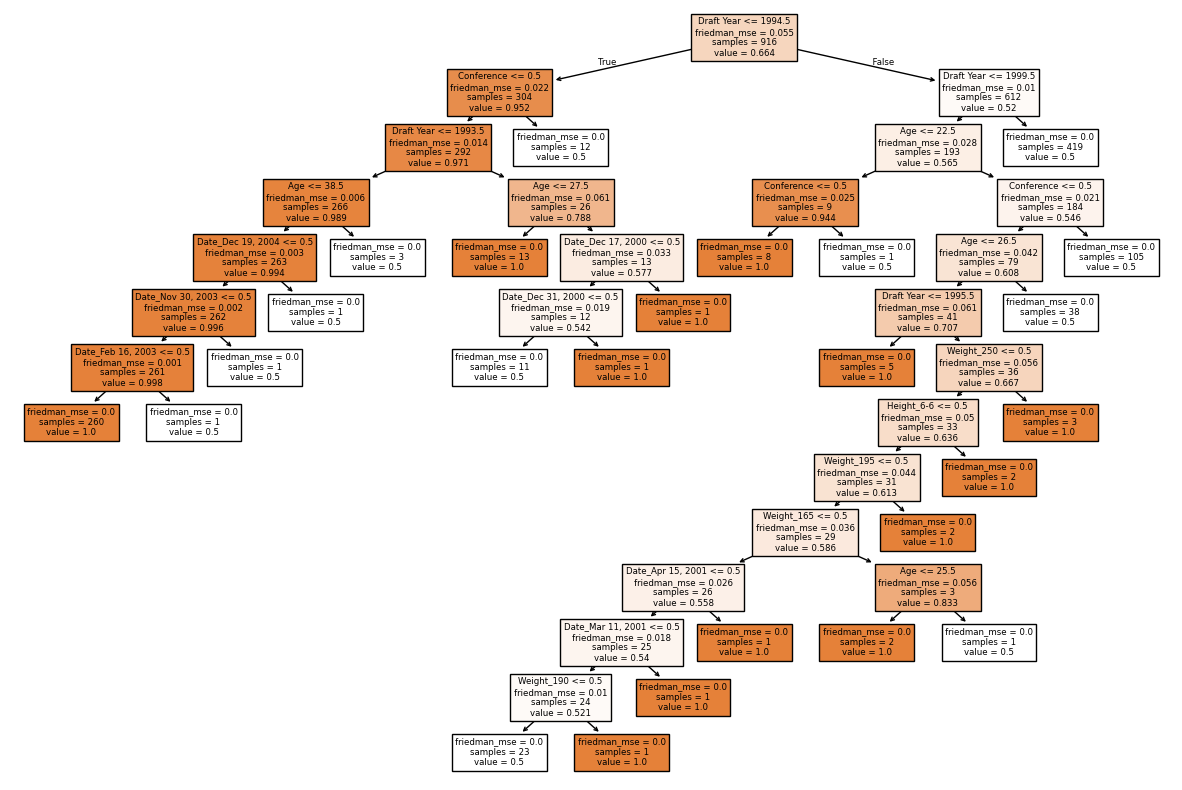

In [44]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))

plot_tree(
    cart,
    feature_names=x.columns,
    class_names=["best perfomance", "not performed"],
    filled=True
)

plt.show()